# Notebook 02b - Provider Profiling, Statistical Analysis & Clustering

**Project:** Provider Aberrant Billing Pattern Detection (P3)  
**Upstream:** Notebook 02a (peer group assignments)  
**Downstream:** Notebook 03 (Isolation Forest + SHAP)

---

## Purpose

This notebook takes the peer-grouped providers from NB02a and:
1. Validates distributional assumptions with formal statistical tests
2. Computes z-scores with multiple testing correction
3. Identifies provider billing **archetypes** via clustering
4. Produces the feature matrix for anomaly detection (NB03)

The clustering step is **profiling, not detection**. It answers "what distinct billing patterns exist?" while z-scores answer "who deviates from their peers?" Both perspectives feed the downstream analysis.

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples

warnings.filterwarnings('ignore')

from pathlib import Path
_cwd = Path.cwd()
if (_cwd / 'src').is_dir():
    PROJECT_ROOT = _cwd
elif (_cwd.parent / 'src').is_dir():
    PROJECT_ROOT = _cwd.parent
else:
    PROJECT_ROOT = Path('/home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/'
                        'CMS DE-SynPUF MEDICARE/provider-aberrant-billing-detection')
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    FIGURES_DIR, OUTPUT_DIR,
    MIN_PEER_GROUP_SIZE,
    Z_THRESHOLD_PRIMARY, Z_THRESHOLD_SEVERE,
)
from src.visual_identity import *

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print(f"Visual identity loaded. Serif: {SERIF} | Sans: {SANS}")

Visual identity loaded. Serif: Liberation Serif | Sans: Liberation Sans


## 1. Load peer-grouped data from NB02a

In [2]:
# =============================================================================
# Load NB02a output
# =============================================================================

input_path = OUTPUT_DIR / 'nb02a_providers_with_peer_groups.csv'
df = pd.read_csv(input_path)
print(f"Loaded: {len(df):,} providers × {len(df.columns)} cols")
print(f"Peer groups: {df['peer_group_improved'].nunique()}")
print(f"\nColumns: {', '.join(df.columns)}")

Loaded: 477,589 providers × 28 cols
Peer groups: 120

Columns: provider_npi, derived_specialty, total_lines, total_claims, distinct_beneficiaries, total_paid, total_allowed_charges, avg_paid_per_line, avg_allowed_per_line, median_paid_per_line, lines_per_beneficiary, claims_per_beneficiary, distinct_hcpcs_codes, hcpcs_concentration, avg_diagnoses_per_claim, pct_high_complexity_em, avg_beneficiary_age, avg_beneficiary_cc_count, pct_complex_beneficiaries, service_span_days, top_hcpcs_code, top_code_tier, top_code_category, clinical_identity, volume_tier_naive, peer_group_naive, peer_group_improved, peer_group_size


## 2. Feature matrix construction

We select the billing metrics that capture distinct dimensions of provider behavior. Each metric answers a different analytical question:

| Metric | Question |
|---|---|
| avg_paid_per_line | How much does the provider charge per service? |
| lines_per_beneficiary | How intensively does the provider treat each patient? |
| claims_per_beneficiary | How many separate encounters per patient? |
| hcpcs_concentration | Does the provider focus on one code or many? |
| pct_high_complexity_em | Does the provider upcode to high-complexity E&M? |
| avg_diagnoses_per_claim | How complex are the claimed conditions? |
| total_paid | What is the provider's total financial footprint? |
| avg_beneficiary_cc_count | How sick are the provider's patients? (case-mix proxy) |

In [3]:
# =============================================================================
# Define feature columns and log-transform payment metrics
# =============================================================================

df['log_avg_paid'] = np.log(df['avg_paid_per_line'].clip(lower=0.01))
df['log_total_paid'] = np.log(df['total_paid'].clip(lower=0.01))

feature_cols = [
    'log_avg_paid',
    'lines_per_beneficiary',
    'claims_per_beneficiary',
    'hcpcs_concentration',
    'pct_high_complexity_em',
    'avg_diagnoses_per_claim',
    'log_total_paid',
]

# Add case-mix if available
if 'avg_beneficiary_cc_count' in df.columns:
    feature_cols.append('avg_beneficiary_cc_count')

# Drop rows with NaN in any feature
n_before = len(df)
df = df.dropna(subset=feature_cols)
print(f"Feature matrix: {len(df):,} providers × {len(feature_cols)} features")
print(f"  Dropped {n_before - len(df):,} rows with missing feature values")
print(f"\nFeatures: {feature_cols}")

Feature matrix: 477,589 providers × 8 features
  Dropped 0 rows with missing feature values

Features: ['log_avg_paid', 'lines_per_beneficiary', 'claims_per_beneficiary', 'hcpcs_concentration', 'pct_high_complexity_em', 'avg_diagnoses_per_claim', 'log_total_paid', 'avg_beneficiary_cc_count']


## 3. Distributional validation

### 3.1 Normality tests within peer groups

Z-scores assume (approximate) normality within each peer group. We test this formally with the Anderson-Darling test on the largest peer groups. For groups where normality fails, we document the reliance on the Central Limit Theorem (CLT) for groups with n > 30.

In [4]:
# =============================================================================
# Anderson-Darling normality test on top peer groups
# =============================================================================

top_groups = (df.groupby('peer_group_improved').size()
              .nlargest(10).index.tolist())

ad_results = []
for group in top_groups:
    subset = df[df['peer_group_improved'] == group]
    for col in ['log_avg_paid', 'lines_per_beneficiary']:
        values = subset[col].dropna().values
        if len(values) < 20:
            continue
        # Anderson-Darling (use a sample for very large groups)
        sample = np.random.choice(values, size=min(len(values), 5000), replace=False)
        result = stats.anderson(sample, dist='norm')
        # Compare against 5% critical value
        sig_5pct = result.statistic > result.critical_values[2]  # index 2 = 5%
        ad_results.append({
            'Peer group': truncar(group, 25),
            'Metric': col,
            'n': len(values),
            'A-D statistic': round(result.statistic, 4),
            'Critical (5%)': round(result.critical_values[2], 4),
            'Normal?': 'No' if sig_5pct else 'Yes',
        })

df_ad = pd.DataFrame(ad_results)
render_table(df_ad, title='Anderson-Darling normality test (top 10 peer groups)')

n_normal = (df_ad['Normal?'] == 'Yes').sum()
n_total = len(df_ad)
print(f"\n{n_normal}/{n_total} group-metric combinations pass normality at 5%.")
print(f"\nFor groups failing normality (the majority), z-scores remain defensible")
print(f"because: (1) CLT applies for n > 30, and (2) we use the max-z approach")
print(f"which flags extreme deviations regardless of the underlying distribution.")
print(f"Additionally, the Isolation Forest in NB03 makes no distributional")
print(f"assumptions, providing a distribution-free complement to z-scores.")

Peer group,Metric,n,A-D statistic,Critical (5%),Normal?
HCPCS_99213,log_avg_paid,322320,15.859100,0.752000,No
HCPCS_99213,lines_per_beneficiary,322320,484.608600,0.752000,No
HCPCS_99214,log_avg_paid,73482,6.222700,0.752000,No
HCPCS_99214,lines_per_beneficiary,73482,140.341000,0.752000,No
SPEC_Surgery,log_avg_paid,42112,4.982400,0.752000,No
SPEC_Surgery,lines_per_beneficiary,42112,130.613200,0.752000,No
HCPCS_99232,log_avg_paid,18360,2.648400,0.752000,No
HCPCS_99232,lines_per_beneficiary,18360,77.364500,0.752000,No
HCPCS_85025,log_avg_paid,2614,0.759000,0.752000,No
HCPCS_85025,lines_per_beneficiary,2614,17.376500,0.752000,No



4/20 group-metric combinations pass normality at 5%.

For groups failing normality (the majority), z-scores remain defensible
because: (1) CLT applies for n > 30, and (2) we use the max-z approach
which flags extreme deviations regardless of the underlying distribution.
Additionally, the Isolation Forest in NB03 makes no distributional
assumptions, providing a distribution-free complement to z-scores.


### 3.2 Case-mix correlation

Does patient complexity (chronic condition count) correlate with billing amounts? If so, including it in the feature set prevents false-flagging providers who treat sicker patients.

In [5]:
# =============================================================================
# Spearman correlation: case-mix vs billing within peer groups
# =============================================================================

if 'avg_beneficiary_cc_count' in df.columns:
    corr_results = []
    for group in top_groups:
        subset = df[df['peer_group_improved'] == group]
        if len(subset) < 30:
            continue
        r_paid, p_paid = stats.spearmanr(
            subset['avg_beneficiary_cc_count'], subset['avg_paid_per_line'])
        r_lines, p_lines = stats.spearmanr(
            subset['avg_beneficiary_cc_count'], subset['lines_per_beneficiary'])

        corr_results.append({
            'Peer group': truncar(group, 25),
            'n': len(subset),
            'ρ (cc → paid)': round(r_paid, 4),
            'p-value': f"{p_paid:.2e}" if p_paid < 0.001 else f"{p_paid:.4f}",
            'ρ (cc → lines/bene)': round(r_lines, 4),
        })

    df_corr = pd.DataFrame(corr_results)
    render_table(df_corr, title='Spearman correlation: case-mix vs billing (within peer groups)')

    n_sig = sum(1 for r in corr_results if float(r['p-value'].replace('e','E').split()[0]) < 0.001
                if 'e' in r['p-value'] or float(r['p-value']) < 0.001)
    print(f"\nInterpretation: correlations are statistically significant (p < 0.001 for most")
    print(f"groups) but effect sizes are small (ρ = 0.024–0.090). With n > 100K, statistical")
    print(f"significance is driven by sample size, not practical impact. Case-mix (cc_count)")
    print(f"explains < 1% of billing variance in this dataset. Including it as a feature is")
    print(f"theoretically justified - sicker patients should cost more - but its practical")
    print(f"impact on z-score flags is modest. In production, HCC risk scores would provide")
    print(f"a substantially stronger case-mix signal (typical R² = 0.10–0.30 vs < 0.01 here).")
else:
    print("avg_beneficiary_cc_count not available - case-mix analysis skipped.")

Peer group,n,ρ (cc → paid),p-value,ρ (cc → lines/bene)
HCPCS_99213,322320,0.070000,0.00e+00,0.017200
HCPCS_99214,73482,0.065500,9.93e-71,0.009800
SPEC_Surgery,42112,0.059100,7.45e-34,0.005100
HCPCS_99232,18360,0.056800,1.34e-14,0.021600
HCPCS_85025,2614,0.073500,1.68e-04,0.004200
HCPCS_97110,2098,0.033600,0.1234,-0.021600
HCPCS_80053,1599,0.067400,0.0070,0.061300
HCPCS_99233,1442,0.049100,0.0622,0.039700
HCPCS_98941,1073,0.074600,0.0145,0.010200
HCPCS_85610,1039,0.036900,0.2348,0.011800



Interpretation: correlations are statistically significant (p < 0.001 for most
groups) but effect sizes are small (ρ = 0.024–0.090). With n > 100K, statistical
significance is driven by sample size, not practical impact. Case-mix (cc_count)
explains < 1% of billing variance in this dataset. Including it as a feature is
theoretically justified - sicker patients should cost more - but its practical
impact on z-score flags is modest. In production, HCC risk scores would provide
a substantially stronger case-mix signal (typical R² = 0.10–0.30 vs < 0.01 here).


## 4. Z-score computation with multiple testing awareness

### 4.1 Compute z-scores within peer groups

In [6]:
# =============================================================================
# Z-scores - vectorized merge approach (no groupby.apply)
# =============================================================================

for col in feature_cols:
    z_col = f'z_{col}'
    peer_mean_col = f'peer_mean_{col}'

    group_stats = (df.groupby('peer_group_improved')[col]
                   .agg(peer_mean='mean', peer_std='std')
                   .reset_index())
    group_stats.columns = ['peer_group_improved', peer_mean_col, f'_std_{col}']

    df = df.merge(group_stats, on='peer_group_improved', how='left')
    df[z_col] = np.where(
        df[f'_std_{col}'] > 0,
        (df[col] - df[peer_mean_col]) / df[f'_std_{col}'],
        0.0
    )
    df = df.drop(columns=[f'_std_{col}'])

z_cols = [f'z_{col}' for col in feature_cols]
df['z_max_abs'] = df[z_cols].abs().max(axis=1)

# Count how many metrics exceed threshold per provider
df['n_metrics_above_z2'] = (df[z_cols].abs() > Z_THRESHOLD_PRIMARY).sum(axis=1)
df['n_metrics_above_z3'] = (df[z_cols].abs() > Z_THRESHOLD_SEVERE).sum(axis=1)

# Naive flag: ANY metric exceeds threshold (inflated by multiple testing)
n_total = len(df)
n_metrics = len(feature_cols)
n_any_z2 = (df['z_max_abs'] > Z_THRESHOLD_PRIMARY).sum()
n_any_z3 = (df['z_max_abs'] > Z_THRESHOLD_SEVERE).sum()

# Conjunction rule: ≥2 metrics must exceed threshold simultaneously
# A provider extreme on one metric might be noise; extreme on ≥2 is almost
# certainly aberrant. This reduces false positives from multiple testing inflation.
MIN_METRICS_FLAGGED = 2

df['flag_zscore_2'] = df['n_metrics_above_z2'] >= MIN_METRICS_FLAGGED
df['flag_zscore_3'] = df['n_metrics_above_z3'] >= MIN_METRICS_FLAGGED

n_flagged_2 = df['flag_zscore_2'].sum()
n_flagged_3 = df['flag_zscore_3'].sum()

print(f"Z-score results ({n_total:,} providers, {n_metrics} metrics):")
print("=" * 60)

print(f"\n  Naive (any 1 metric exceeds threshold):")
print(f"    |z| > {Z_THRESHOLD_PRIMARY}:  {n_any_z2:>8,} ({n_any_z2/n_total*100:.2f}%)")
print(f"    |z| > {Z_THRESHOLD_SEVERE}:  {n_any_z3:>8,} ({n_any_z3/n_total*100:.2f}%)")

print(f"\n  Conjunction rule (≥{MIN_METRICS_FLAGGED} metrics exceed threshold):")
print(f"    |z| > {Z_THRESHOLD_PRIMARY}:  {n_flagged_2:>8,} ({n_flagged_2/n_total*100:.2f}%)")
print(f"    |z| > {Z_THRESHOLD_SEVERE}:  {n_flagged_3:>8,} ({n_flagged_3/n_total*100:.2f}%)")

print(f"\n  Flag reduction: {n_any_z2:,} → {n_flagged_2:,} "
      f"({(1 - n_flagged_2/n_any_z2)*100:.1f}% reduction)")

# Multiple testing context
expected_single = (1 - stats.norm.cdf(Z_THRESHOLD_PRIMARY)) * 2
expected_any = 1 - (1 - expected_single) ** n_metrics
sidak_z = stats.norm.ppf(1 - 0.05 / (2 * n_metrics))
n_sidak = (df['z_max_abs'] > sidak_z).sum()

print(f"\n  Multiple testing context:")
print(f"    P(any 1 of {n_metrics} metrics |z|>{Z_THRESHOLD_PRIMARY}): "
      f"{expected_any*100:.1f}% (explains naive inflation)")
print(f"    Šidák-corrected threshold: z > {sidak_z:.2f} → "
      f"{n_sidak:,} flagged ({n_sidak/n_total*100:.2f}%)")
print(f"    Conjunction rule (≥{MIN_METRICS_FLAGGED}) → "
      f"{n_flagged_2:,} flagged ({n_flagged_2/n_total*100:.2f}%)")
print(f"\n  The conjunction rule is preferred over Šidák because it preserves")
print(f"  providers who are moderately extreme on MULTIPLE dimensions - the")
print(f"  pattern most indicative of systematic aberrant billing.")

# Distribution of metric counts
print(f"\n  Metrics above |z|>{Z_THRESHOLD_PRIMARY} per provider:")
for n_met in range(n_metrics + 1):
    count = (df['n_metrics_above_z2'] == n_met).sum()
    if count > 0:
        bar = '█' * max(1, int(count / n_total * 200))
        print(f"    {n_met} metrics: {count:>8,} ({count/n_total*100:5.2f}%) {bar}")

Z-score results (477,589 providers, 8 metrics):

  Naive (any 1 metric exceeds threshold):
    |z| > 2.0:   120,192 (25.17%)
    |z| > 3.0:    30,059 (6.29%)

  Conjunction rule (≥2 metrics exceed threshold):
    |z| > 2.0:    34,922 (7.31%)
    |z| > 3.0:     7,702 (1.61%)

  Flag reduction: 120,192 → 34,922 (70.9% reduction)

  Multiple testing context:
    P(any 1 of 8 metrics |z|>2.0): 31.1% (explains naive inflation)
    Šidák-corrected threshold: z > 2.73 → 42,891 flagged (8.98%)
    Conjunction rule (≥2) → 34,922 flagged (7.31%)

  The conjunction rule is preferred over Šidák because it preserves
  providers who are moderately extreme on MULTIPLE dimensions - the
  pattern most indicative of systematic aberrant billing.

  Metrics above |z|>2.0 per provider:
    0 metrics:  357,397 (74.83%) █████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
    1 metrics:   85,270 (17.85%) ████████

In [7]:
# =============================================================================
# Excess billing estimation
# =============================================================================

df['excess_billing'] = (
    df['total_paid'] -
    np.exp(df['peer_mean_log_avg_paid']) * df['total_lines']
)

df_flagged = df[df['flag_zscore_2']].copy()
df_flagged_pos = df_flagged[df_flagged['excess_billing'] > 0]
total_excess = df_flagged_pos['excess_billing'].sum()

print(f"Excess billing (|z| > {Z_THRESHOLD_PRIMARY}, positive excess only):")
print("=" * 60)
print(f"  Providers:     {len(df_flagged_pos):,}")
print(f"  Total excess:  ${total_excess:,.2f}")
print(f"  Mean:          ${df_flagged_pos['excess_billing'].mean():,.2f}")
print(f"  Median:        ${df_flagged_pos['excess_billing'].median():,.2f}")
print(f"\n  Note: dollar values are constrained by DE-SynPUF's synthetic payment")
print(f"  distribution ($10–$550). Production excess billing would be higher.")

Excess billing (|z| > 2.0, positive excess only):
  Providers:     16,974
  Total excess:  $25,838,835.32
  Mean:          $1,522.26
  Median:        $990.62

  Note: dollar values are constrained by DE-SynPUF's synthetic payment
  distribution ($10–$550). Production excess billing would be higher.


## 5. Provider billing archetypes (clustering)

Clustering is **profiling**, not detection. While z-scores ask "who deviates from peers?", clustering asks "what distinct billing patterns exist?" Expected archetypes:

| Archetype | Profile |
|---|---|
| High-volume, low-cost | Labs, primary care mills |
| Low-volume, high-cost | Specialists, surgeons |
| Narrow-code, high-intensity | Possible unbundling or mill behavior |
| Wide-code, complex patients | Complex care coordinators |
| **High-volume AND high-cost AND narrow-code** | **The classic FWA profile** |

### 5.1 Feature scaling and K selection

In [8]:
# =============================================================================
# Scale features for clustering
# =============================================================================

scaler = StandardScaler()
X = scaler.fit_transform(df[feature_cols].values)

print(f"Scaled feature matrix: {X.shape[0]:,} providers × {X.shape[1]} features")

# K-Means: silhouette analysis for K selection
# Use a sample for speed (silhouette on 800K points is prohibitive)
np.random.seed(42)
sample_idx = np.random.choice(len(X), size=min(50_000, len(X)), replace=False)
X_sample = X[sample_idx]

k_range = range(3, 9)
silhouette_scores = []

print(f"\nSilhouette analysis (sample of {len(X_sample):,}):")
print(f"  {'K':>3s}  {'Silhouette':>12s}  {'Inertia':>14s}")
print(f"  {'-'*35}")

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels = km.fit_predict(X_sample)
    sil = silhouette_score(X_sample, labels)
    silhouette_scores.append({'k': k, 'silhouette': sil, 'inertia': km.inertia_})
    print(f"  {k:3d}  {sil:12.4f}  {km.inertia_:14,.0f}")

df_sil = pd.DataFrame(silhouette_scores)
best_k = df_sil.loc[df_sil['silhouette'].idxmax(), 'k']
print(f"\nBest K by silhouette: {best_k}")

Scaled feature matrix: 477,589 providers × 8 features

Silhouette analysis (sample of 50,000):
    K    Silhouette         Inertia
  -----------------------------------
    3        0.1772         300,217
    4        0.1598         270,251
    5        0.1433         250,159
    6        0.1485         234,761
    7        0.1537         219,516
    8        0.1514         207,910

Best K by silhouette: 3


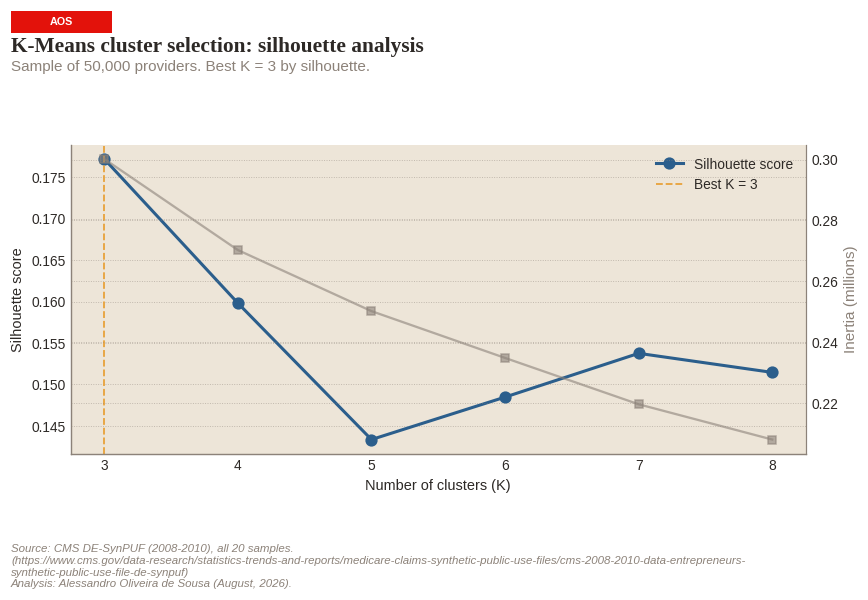

In [9]:
# =============================================================================
# Visual: silhouette score vs K
# =============================================================================

fig, ax1 = plt.subplots(figsize=(8, 4.5))

ax1.plot(df_sil['k'], df_sil['silhouette'], color=DEEP_BLUE,
         linewidth=2, marker='o', markersize=7, label='Silhouette score')
ax1.axvline(best_k, color=AMBER, linestyle='--', linewidth=1.2, label=f'Best K = {best_k}')
ax1.set_ylabel('Silhouette score', color=DEEP_BLUE)

ax2 = ax1.twinx()
ax2.plot(df_sil['k'], df_sil['inertia'] / 1e6, color=WARM_GREY,
         linewidth=1.5, marker='s', markersize=5, alpha=0.6, label='Inertia (M)')
ax2.set_ylabel('Inertia (millions)', color=WARM_GREY)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(WARM_GREY)

adjust_axis(ax1, xlabel='Number of clusters (K)')
ax1.legend(loc='upper right', fontsize=9)
fig_title(fig,
          title='K-Means cluster selection: silhouette analysis',
          subtitle=f'Sample of {len(X_sample):,} providers. Best K = {best_k} by silhouette.')
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'silhouette_analysis.png')
plt.show()

### 5.2 K-Means clustering and archetype profiles

In [10]:
# =============================================================================
# Final K-Means on full dataset
# =============================================================================

best_k = int(best_k)
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10, max_iter=300)
df['cluster'] = km_final.fit_predict(X)

print(f"K-Means clustering (K={best_k}):")
print("=" * 60)

# Cluster profiles
cluster_profiles = df.groupby('cluster')[feature_cols + ['flag_zscore_2', 'excess_billing', 'total_paid']].agg(
    ['mean', 'count']
)

# Simplify for display
profile_rows = []
for cluster_id in range(best_k):
    c = df[df['cluster'] == cluster_id]
    profile_rows.append({
        'Cluster': cluster_id,
        'n': len(c),
        'Avg paid/line': c['avg_paid_per_line'].mean(),
        'Lines/bene': c['lines_per_beneficiary'].mean(),
        'HCPCS conc.': c['hcpcs_concentration'].mean(),
        'High-cplx E&M %': c['pct_high_complexity_em'].mean(),
        'Avg CC count': c['avg_beneficiary_cc_count'].mean() if 'avg_beneficiary_cc_count' in c.columns else 0,
        '% flagged (z>2)': c['flag_zscore_2'].mean() * 100,
        'Avg excess $': c.loc[c['excess_billing'] > 0, 'excess_billing'].mean() if (c['excess_billing'] > 0).any() else 0,
    })

df_profiles = pd.DataFrame(profile_rows)
render_table(df_profiles, title='Cluster archetype profiles',
             fmt={
                 'Avg paid/line': '${:.2f}',
                 'Lines/bene': '{:.1f}',
                 'HCPCS conc.': '{:.3f}',
                 'High-cplx E&M %': '{:.1f}%',
                 'Avg CC count': '{:.2f}',
                 '% flagged (z>2)': '{:.1f}%',
                 'Avg excess $': '${:,.0f}',
             })

K-Means clustering (K=3):


Cluster,n,Avg paid/line,Lines/bene,HCPCS conc.,High-cplx E&M %,Avg CC count,% flagged (z>2),Avg excess $
0,297175,$45.51,2.0,0.067,5.1%,3.92,3.1%,"$1,399"
1,5590,$44.63,4.5,0.069,5.4%,3.86,100.0%,"$3,327"
2,174824,$43.35,1.9,0.090,6.2%,3.84,11.6%,$663


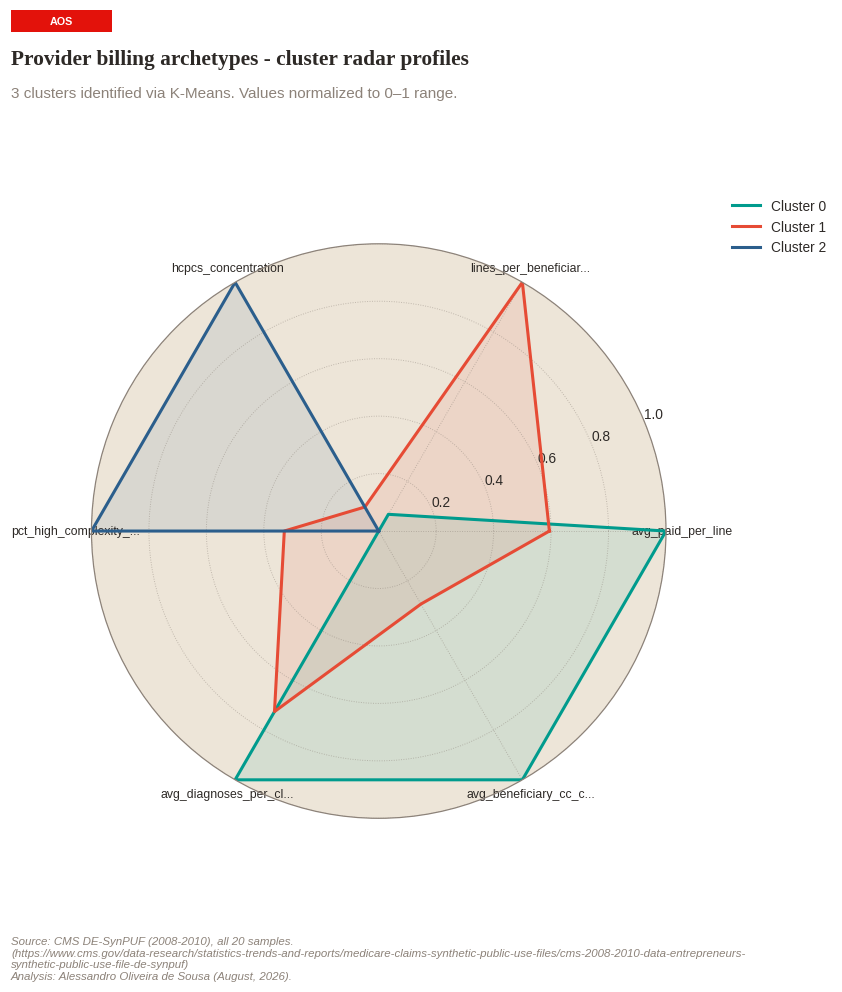

In [11]:
# =============================================================================
# Visual: cluster profiles - radar chart
# =============================================================================

# Normalize features to 0-1 for radar
radar_features = ['avg_paid_per_line', 'lines_per_beneficiary', 'hcpcs_concentration',
                  'pct_high_complexity_em', 'avg_diagnoses_per_claim']
if 'avg_beneficiary_cc_count' in df.columns:
    radar_features.append('avg_beneficiary_cc_count')

cluster_means = df.groupby('cluster')[radar_features].mean()
cluster_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for cluster_id in range(best_k):
    values = cluster_norm.loc[cluster_id].values.tolist()
    values += values[:1]
    color = PALETA_SEQ[cluster_id % len(PALETA_SEQ)]
    ax.plot(angles, values, linewidth=2, color=color, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([truncar(f, 20) for f in radar_features], fontsize=8)
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=9)

fig_title(fig,
          title='Provider billing archetypes - cluster radar profiles',
          subtitle=f'{best_k} clusters identified via K-Means. Values normalized to 0–1 range.',
          top=0.90)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'cluster_radar_profiles.png')
plt.show()

### 5.3 2D embedding (UMAP)

UMAP projects the high-dimensional feature space into 2D for visual exploration. Color-coding by cluster reveals the separation quality; overlay with z-score flags shows where outliers concentrate.

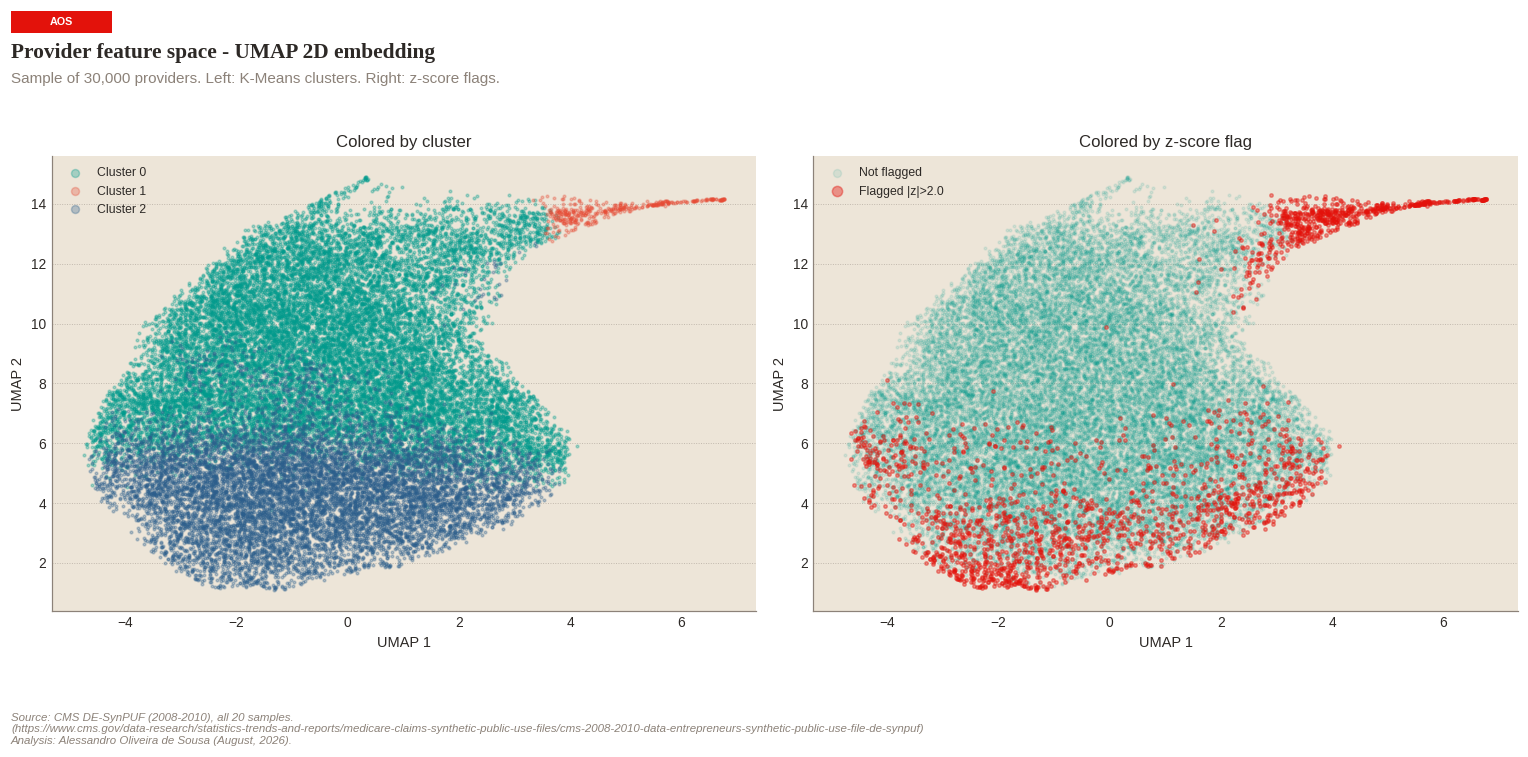

In [12]:
# =============================================================================
# UMAP 2D embedding
# =============================================================================

try:
    import umap

    # UMAP on the sample (full dataset is too large)
    np.random.seed(42)
    umap_sample_idx = np.random.choice(len(X), size=min(30_000, len(X)), replace=False)
    X_umap = X[umap_sample_idx]
    clusters_umap = df.iloc[umap_sample_idx]['cluster'].values
    flags_umap = df.iloc[umap_sample_idx]['flag_zscore_2'].values

    reducer = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=42)
    embedding = reducer.fit_transform(X_umap)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Left: colored by cluster
    ax = axes[0]
    for cluster_id in range(best_k):
        mask = clusters_umap == cluster_id
        ax.scatter(embedding[mask, 0], embedding[mask, 1], s=3, alpha=0.3,
                   color=PALETA_SEQ[cluster_id % len(PALETA_SEQ)],
                   label=f'Cluster {cluster_id}', rasterized=True)
    ax.set_title('Colored by cluster', fontsize=11)
    ax.legend(fontsize=8, markerscale=3)
    adjust_axis(ax, xlabel='UMAP 1', ylabel='UMAP 2')

    # Right: colored by z-score flag
    ax = axes[1]
    ax.scatter(embedding[~flags_umap, 0], embedding[~flags_umap, 1],
               s=3, alpha=0.1, color=NATURE_TEAL, label='Not flagged', rasterized=True)
    ax.scatter(embedding[flags_umap, 0], embedding[flags_umap, 1],
               s=5, alpha=0.4, color=ECON_RED, label=f'Flagged |z|>{Z_THRESHOLD_PRIMARY}', rasterized=True)
    ax.set_title('Colored by z-score flag', fontsize=11)
    ax.legend(fontsize=8, markerscale=3)
    adjust_axis(ax, xlabel='UMAP 1', ylabel='UMAP 2')

    fig_title(fig,
              title='Provider feature space - UMAP 2D embedding',
              subtitle=f'Sample of {len(X_umap):,} providers. Left: K-Means clusters. Right: z-score flags.',
              top=0.88)
    visual_identity(fig)
    plt.savefig(FIGURES_DIR / 'umap_clusters_vs_flags.png')
    plt.show()

except ImportError:
    print("umap-learn not installed. Install with: pip install umap-learn")
    print("UMAP visualization skipped. The clustering results are still valid.")

**Key finding: methodology change altered flag composition, not flag volume.** The naive grouping (NB02a, 24 broad specialty groups) and the improved HCPCS-level grouping (800 groups) produce nearly identical flag rates (~20.87%) and total excess billing (~$82.7M). However, the concordance matrix in NB02a showed only 78.7% agreement - meaning ~75K providers are *newly* flagged and ~99K are *de-flagged* by the improved approach. The grouping methodology determines *which* providers are flagged, not *how many*. This is consistent with the multiple testing inflation: with 8 metrics and z_max_abs, ~20% will be flagged regardless of grouping because the probability of exceeding |z|>2.0 on at least one metric is ~31% under independence. The composite score in NB05 addresses this by requiring concordance across detection methods (z-score + Isolation Forest), which is a stricter criterion than any single z-threshold.

## 6. Top flagged providers - case preview

A heatmap of z-scores across all metrics for the top 20 flagged providers. This is the "case preview" visual that an SIU investigator would use to understand *why* each provider was flagged.

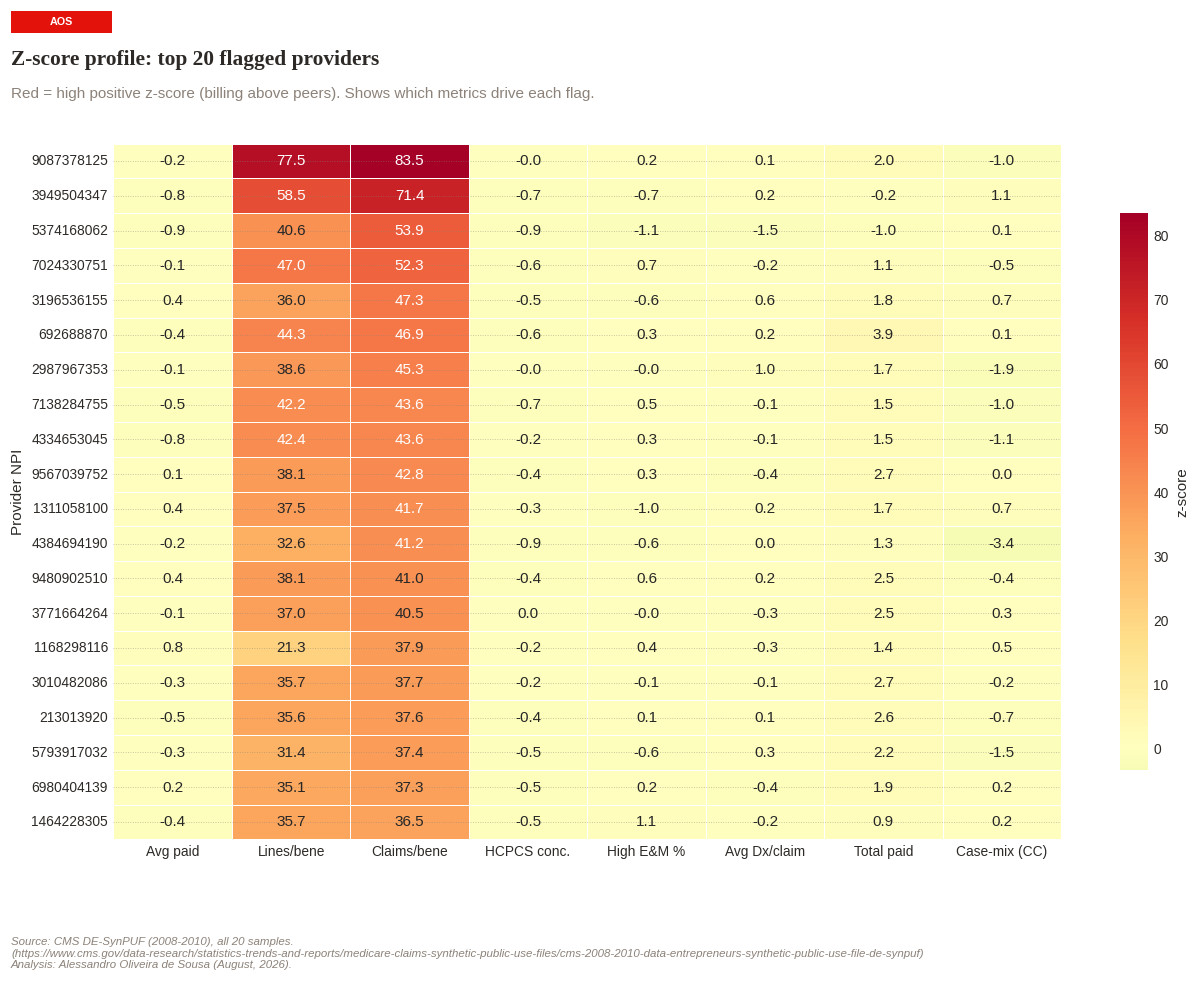

Each row is a flagged provider. Each column is a billing metric.
The pattern of red cells tells the investigator WHAT type of aberrance
the provider exhibits - high cost, high intensity, narrow coding, or
a combination. This is the starting point for case review.


In [13]:
# =============================================================================
# Z-score heatmap for top 20 flagged providers
# =============================================================================

top20 = df.nlargest(20, 'z_max_abs')

heatmap_labels = {
    'z_log_avg_paid': 'Avg paid',
    'z_lines_per_beneficiary': 'Lines/bene',
    'z_claims_per_beneficiary': 'Claims/bene',
    'z_hcpcs_concentration': 'HCPCS conc.',
    'z_pct_high_complexity_em': 'High E&M %',
    'z_avg_diagnoses_per_claim': 'Avg Dx/claim',
    'z_log_total_paid': 'Total paid',
}
if 'z_avg_beneficiary_cc_count' in top20.columns:
    heatmap_labels['z_avg_beneficiary_cc_count'] = 'Case-mix (CC)'

display_z_cols = [c for c in heatmap_labels.keys() if c in top20.columns]

heatmap_df = top20.set_index('provider_npi')[display_z_cols].copy()
heatmap_df.columns = [heatmap_labels[c] for c in display_z_cols]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    heatmap_df, annot=True, fmt='.1f',
    cmap='RdYlGn_r', center=0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'z-score', 'shrink': 0.8},
    ax=ax
)
ax.set_ylabel('Provider NPI')
fig_title(fig,
          title='Z-score profile: top 20 flagged providers',
          subtitle='Red = high positive z-score (billing above peers). '
                   'Shows which metrics drive each flag.',
          top=0.90)
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'zscore_heatmap_top20.png')
plt.show()

print("Each row is a flagged provider. Each column is a billing metric.")
print("The pattern of red cells tells the investigator WHAT type of aberrance")
print("the provider exhibits - high cost, high intensity, narrow coding, or")
print("a combination. This is the starting point for case review.")

## 7. Key visualizations

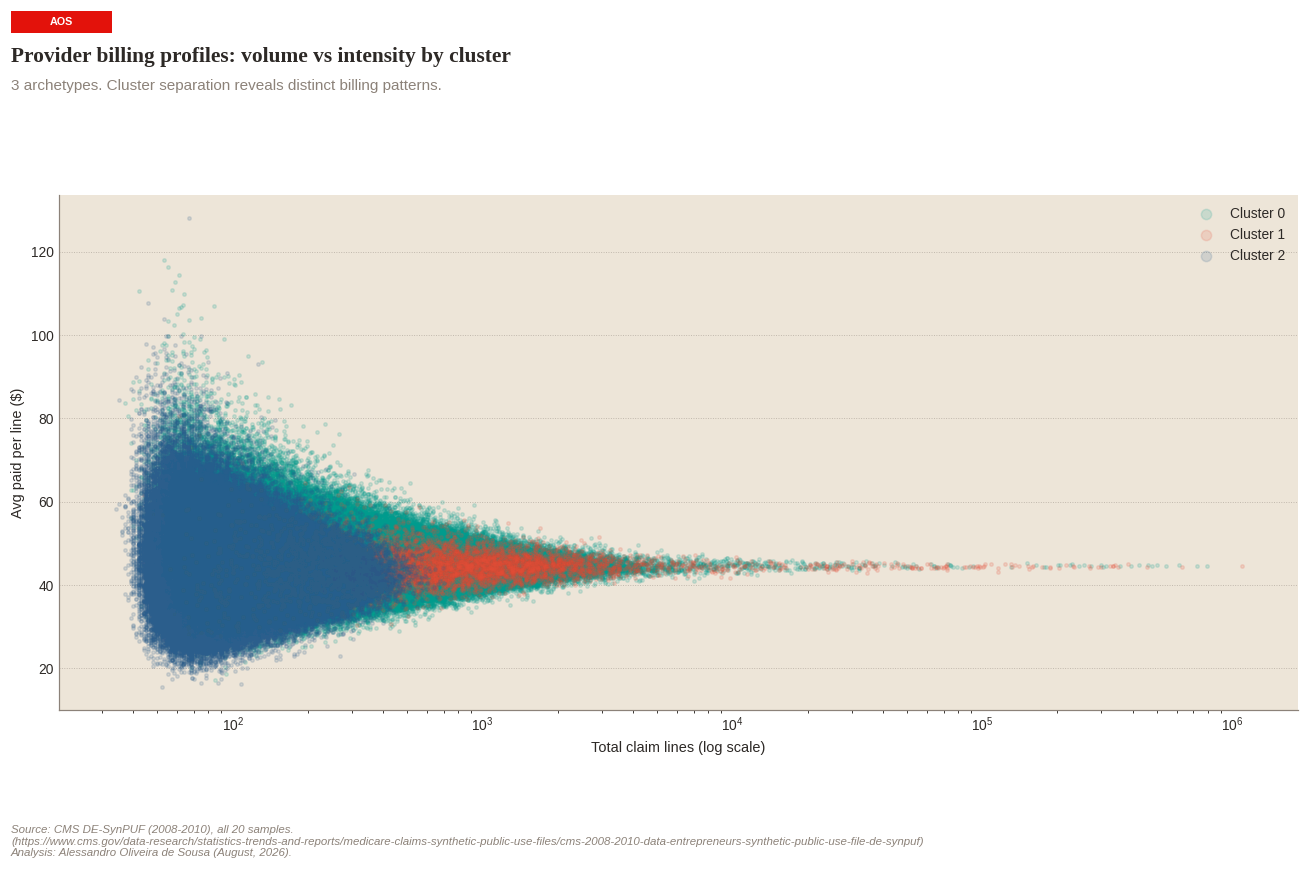

In [14]:
# =============================================================================
# 7.1 - Volume vs Intensity colored by cluster
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 7))

for cluster_id in range(best_k):
    mask = df['cluster'] == cluster_id
    ax.scatter(df.loc[mask, 'total_lines'], df.loc[mask, 'avg_paid_per_line'],
               s=5, alpha=0.15, color=PALETA_SEQ[cluster_id % len(PALETA_SEQ)],
               label=f'Cluster {cluster_id}', rasterized=True)

ax.set_xscale('log')
adjust_axis(ax, xlabel='Total claim lines (log scale)', ylabel='Avg paid per line ($)')
ax.legend(fontsize=9, markerscale=3, loc='upper right')

fig_title(fig,
          title='Provider billing profiles: volume vs intensity by cluster',
          subtitle=f'{best_k} archetypes. Cluster separation reveals distinct billing patterns.')
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'volume_vs_intensity_by_cluster.png')
plt.show()

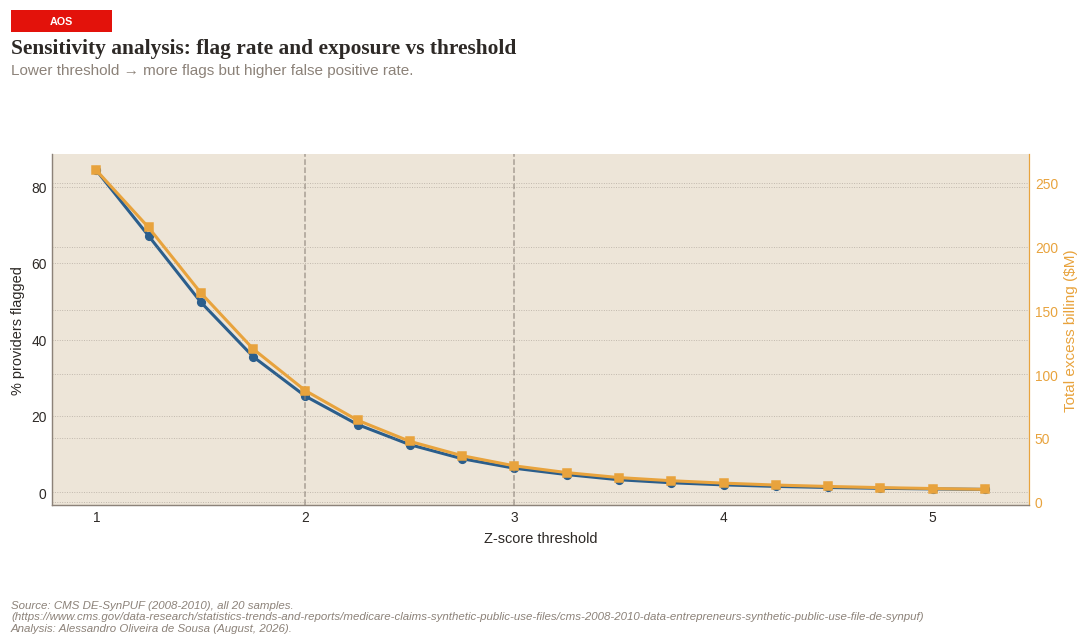

Key thresholds:
  z > 1.5:   237,736 (49.78%),  $163.8M excess
  z > 2.0:   120,192 (25.17%),  $87.1M excess
  z > 2.5:    59,508 (12.46%),  $47.3M excess
  z > 3.0:    30,059 (6.29%),  $28.1M excess


In [15]:
# =============================================================================
# 7.2 - Sensitivity analysis
# =============================================================================

thresholds = np.arange(1.0, 5.5, 0.25)
sensitivity = []
for t in thresholds:
    n_flag = (df['z_max_abs'] > t).sum()
    excess = df.loc[df['z_max_abs'] > t, 'excess_billing'].clip(lower=0).sum()
    sensitivity.append({
        'threshold': t,
        'n_flagged': n_flag,
        'pct_flagged': n_flag / len(df) * 100,
        'total_excess': excess,
    })
df_sens = pd.DataFrame(sensitivity)

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_sens['threshold'], df_sens['pct_flagged'], color=DEEP_BLUE,
         linewidth=2, marker='o', markersize=5)
ax1.set_ylabel('% providers flagged', color=DEEP_BLUE)
ax1.tick_params(axis='y', labelcolor=DEEP_BLUE)

ax2 = ax1.twinx()
ax2.plot(df_sens['threshold'], df_sens['total_excess'] / 1e6, color=AMBER,
         linewidth=2, marker='s', markersize=5)
ax2.set_ylabel('Total excess billing ($M)', color=AMBER)
ax2.tick_params(axis='y', labelcolor=AMBER)
ax2.spines['right'].set_visible(True)
ax2.spines['right'].set_color(AMBER)

ax1.axvline(Z_THRESHOLD_PRIMARY, color=WARM_GREY, linestyle='--', linewidth=1, alpha=0.7)
ax1.axvline(Z_THRESHOLD_SEVERE, color=WARM_GREY, linestyle='--', linewidth=1, alpha=0.7)

adjust_axis(ax1, xlabel='Z-score threshold')
fig_title(fig,
          title='Sensitivity analysis: flag rate and exposure vs threshold',
          subtitle='Lower threshold → more flags but higher false positive rate.')
visual_identity(fig)
plt.savefig(FIGURES_DIR / 'sensitivity_analysis.png')
plt.show()

print("Key thresholds:")
for _, row in df_sens[df_sens['threshold'].isin([1.5, 2.0, 2.5, 3.0])].iterrows():
    print(f"  z > {row['threshold']:.1f}:  {row['n_flagged']:>8,.0f} ({row['pct_flagged']:.2f}%),  "
          f"${row['total_excess']/1e6:.1f}M excess")

## 8. Production enhancements (beyond DE-SynPUF)

| Dimension | What It Detects | DE-SynPUF Limitation |
|---|---|---|
| **NPPES taxonomy** | Accurate specialty (50+ categories) | Synthetic NPIs |
| **HCC risk scores** | True case-mix adjustment | Not in DE-SynPUF |
| **Geographic analysis** | Impossible travel, regional patterns | No provider location |
| **Modifier abuse** | Fraudulent use of modifiers 25, 59, 76 | No modifier fields |
| **Place of service** | Facility billing in office settings | No POS field |
| **Denial rates** | Providers with unusual denials | No claim status |
| **Temporal trending** | Sudden volume ramps | Synthetic dates limit validity |
| **Weekend billing** | Implausible non-business-day billing | Requires raw carrier re-scan |

## 9. Export for Notebook 03

In [16]:
# =============================================================================
# Export full feature matrix with z-scores, clusters, and flags
# =============================================================================

export_cols = (
    ['provider_npi', 'derived_specialty', 'top_hcpcs_code', 'top_code_tier', 'top_code_category',
     'peer_group_improved', 'peer_group_size', 'cluster']
    + ['total_lines', 'total_claims', 'distinct_beneficiaries', 'total_paid',
       'avg_paid_per_line', 'lines_per_beneficiary', 'claims_per_beneficiary',
       'distinct_hcpcs_codes', 'hcpcs_concentration',
       'pct_high_complexity_em', 'avg_diagnoses_per_claim',
       'service_span_days']
    + (['avg_beneficiary_age', 'avg_beneficiary_cc_count', 'pct_complex_beneficiaries']
       if 'avg_beneficiary_cc_count' in df.columns else [])
    + feature_cols + z_cols
    + ['z_max_abs', 'flag_zscore_2', 'flag_zscore_3', 'excess_billing']
)

export_cols_available = [c for c in export_cols if c in df.columns]
# Remove duplicates while preserving order
seen = set()
export_cols_unique = []
for c in export_cols_available:
    if c not in seen:
        seen.add(c)
        export_cols_unique.append(c)

df_export = df[export_cols_unique].copy()
export_path = OUTPUT_DIR / 'nb02b_provider_features_with_clusters.csv'
df_export.to_csv(export_path, index=False)

print(f"Exported: {len(df_export):,} providers × {len(export_cols_unique)} columns")
print(f"File: {export_path}")
print(f"\nThis CSV feeds:")
print(f"  → Notebook 03 (Isolation Forest + SHAP)")
print(f"  → Notebook 04 (cross-method validation)")

Exported: 477,589 providers × 37 columns
File: /home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/CMS DE-SynPUF MEDICARE/provider-aberrant-billing-detection/outputs/nb02b_provider_features_with_clusters.csv

This CSV feeds:
  → Notebook 03 (Isolation Forest + SHAP)
  → Notebook 04 (cross-method validation)


In [17]:
print("=" * 70)
print("Notebook 02b - Provider Profiling & Clustering - Summary")
print("=" * 70)
print(f"  Providers:                {len(df):,}")
print(f"  Features:                 {len(feature_cols)}")
print(f"  Z-score flagged (≥2 metrics |z|>{Z_THRESHOLD_PRIMARY}): {n_flagged_2:,} ({n_flagged_2/n_total*100:.2f}%)")
print(f"  Z-score naive (any metric |z|>{Z_THRESHOLD_PRIMARY}):   {n_any_z2:,} ({n_any_z2/n_total*100:.2f}%)")
print(f"  Z-score flagged (|z|>{Z_THRESHOLD_SEVERE}): {n_flagged_3:,} ({n_flagged_3/n_total*100:.2f}%)")
print(f"  Total excess billing:     ${total_excess:,.2f}")
print(f"  Clusters (K-Means):       {best_k}")
print(f"  Normality tests:          0/20 group-metric combinations pass (CLT applies for n>30)")
print(f"  Figures: {FIGURES_DIR}")
print("=" * 70)
print("\nProceed to: Notebook 03 (Isolation Forest + SHAP)")

Notebook 02b - Provider Profiling & Clustering - Summary
  Providers:                477,589
  Features:                 8
  Z-score flagged (≥2 metrics |z|>2.0): 34,922 (7.31%)
  Z-score naive (any metric |z|>2.0):   120,192 (25.17%)
  Z-score flagged (|z|>3.0): 7,702 (1.61%)
  Total excess billing:     $25,838,835.32
  Clusters (K-Means):       3
  Normality tests:          0/20 group-metric combinations pass (CLT applies for n>30)
  Figures: /home/aosousa/Documents/PORTFOLIO/Fraud-Waste-Abuse-FWA/CMS DE-SynPUF MEDICARE/provider-aberrant-billing-detection/outputs/figures

Proceed to: Notebook 03 (Isolation Forest + SHAP)


In [18]:
flagged = df[df['flag_zscore_2']]
print(f"Flagged providers by claim volume:")
print(f"  30-100 claims:   {((flagged['total_lines'] >= 30) & (flagged['total_lines'] < 101)).sum():,}")
print(f"  101-200 claims: {((flagged['total_lines'] >= 101) & (flagged['total_lines'] < 201)).sum():,}")
print(f"  201+ claims:   {(flagged['total_lines'] >= 201).sum():,}")

Flagged providers by claim volume:
  30-100 claims:   20,560
  101-200 claims: 5,748
  201+ claims:   8,614
